Data Science Project #1: Bank Customer Churn Analysis using a Classification Model
Goal: Get back into Python and learn about different classification ML models
Models Used: RandomForestClassifier, SVM, KNN

In [32]:
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

#for data processing and testing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

#importing models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

#importing performance KPIs
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, recall_score, f1_score, classification_report

In [2]:
#Set working directory
os.chdir('/Users/michaelyoo/Documents/Projects/Python Projects/Bank Customer Churn Project')

In [7]:
#Read in data
df = pd.read_csv("Churn_Modeling.csv")
print(df.head(10))

#Get rid of junk columns
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis = 1)

#One Hot Encode categorical variables to add them as features, drop first to prevent multicollinearity
df_encoded = pd.get_dummies(df, columns = ['Gender', 'Geography'], drop_first=True)

print(df_encoded.head())
df = df_encoded

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   
5          6    15574012       Chu          645     Spain    Male   44   
6          7    15592531  Bartlett          822    France    Male   50   
7          8    15656148    Obinna          376   Germany  Female   29   
8          9    15792365        He          501    France    Male   44   
9         10    15592389        H?          684    France    Male   27   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0       

In [8]:
#Exploratory data analysis
print(df["Exited"].describe())

#Class imbalance, 20 percent churn, 80 percent not churn

count    10000.000000
mean         0.203700
std          0.402769
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Exited, dtype: float64


In [9]:
#Set y and X
y = df["Exited"]
x = df.drop("Exited", axis = 1)

#Split data into training and test set
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.70,random_state=42)

In [24]:
#Logistic Regression
logistic_mod = make_pipeline(StandardScaler(),
                             LogisticRegression(max_iter=1000))
logistic_mod.fit(x_train,y_train)
y_pred = logistic_mod.predict(x_test)
logistic_mod.score(x_test, y_test)

0.8113333333333334

In [25]:
#Random Forest Classifier
rf_mod = RandomForestClassifier()
rf_mod.fit(x_train,y_train)
y_pred = rf_mod.predict(x_test)
rf_mod.score(x_test, y_test)

0.8686666666666667

In [ ]:
#K Nearest Neighbors
knn_mod = KNeighborsClassifier(n_neighbors=100)
knn_mod.fit(x_train,y_train)
y_pred = knn_mod.predict(x_test)
knn_mod.score(x_test, y_test)

0.8053333333333333

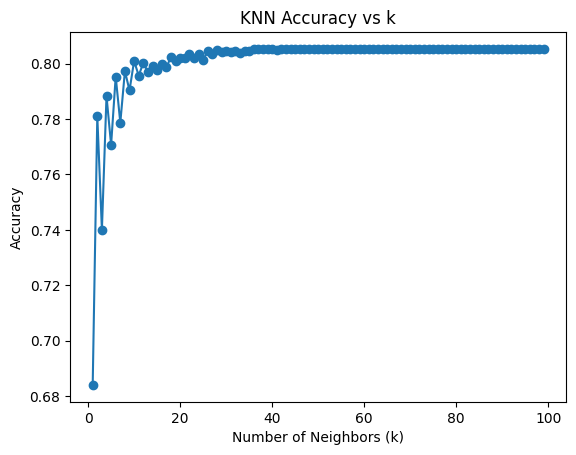

Highest score: 0.8053333333333333
Optimal N neighbors: 36


In [ ]:
#Loop to find optimal N
score_vec = []
n_values = range(1, 100)
best_score = 0
best_n = 0
for n in n_values:
    knn_mod = KNeighborsClassifier(n_neighbors=n)
    knn_mod.fit(x_train,y_train)
    score = knn_mod.score(x_test, y_test)
    if score > best_score:
        best_score = score
        best_n = n
    score_vec.append(score)

plt.plot(n_values, score_vec, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs k')
plt.show()

print(f"Highest score: {best_score}")
print(f"Optimal N neighbors: {best_n}")

SVM parameters
- Used one-versus-one since we are determining customer churn
- Disproportional training set, only 20% of customers have exited
- 

In [31]:
#SVM
svm_mod = SVC(kernel='rbf', probability=True)
svm_mod.fit(x_train,y_train)
y_pred = svm_mod.predict(x_test)
svm_mod.score(x_test, y_test)

0.8053333333333333

In [11]:
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
model.score(x_test, y_test)

0.8673333333333333

In [75]:
#Score metrics

# Counts of true/false positives and negatives
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Overall correctness of the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Out of predicted positives, how many are correct
precision = precision_score(y_test, y_pred, average='binary')
print("Precision:", precision)

# Out of actual positives, how many did the model detect
recall = recall_score(y_test, y_pred, average='binary')
print("Recall:", recall)

# Harmonic mean of precision and recall, balancing both
f1 = f1_score(y_test, y_pred, average='binary')
print("F1 Score:", f1)

Confusion Matrix:
 [[2334   82]
 [ 311  273]]
Accuracy: 0.869
Precision: 0.7690140845070422
Recall: 0.4674657534246575
F1 Score: 0.5814696485623003
